<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_779/592306332.py:30: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(N_line, P_opt, Z_opt, color='black', lw=5, label='Optimal Scale: $P_{opt} \propto N^{2/3}$')
/tmp/ipykernel_779/592306332.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax.set_zlabel('Total Heat Dissipation ($\delta$)', fontsize=12)


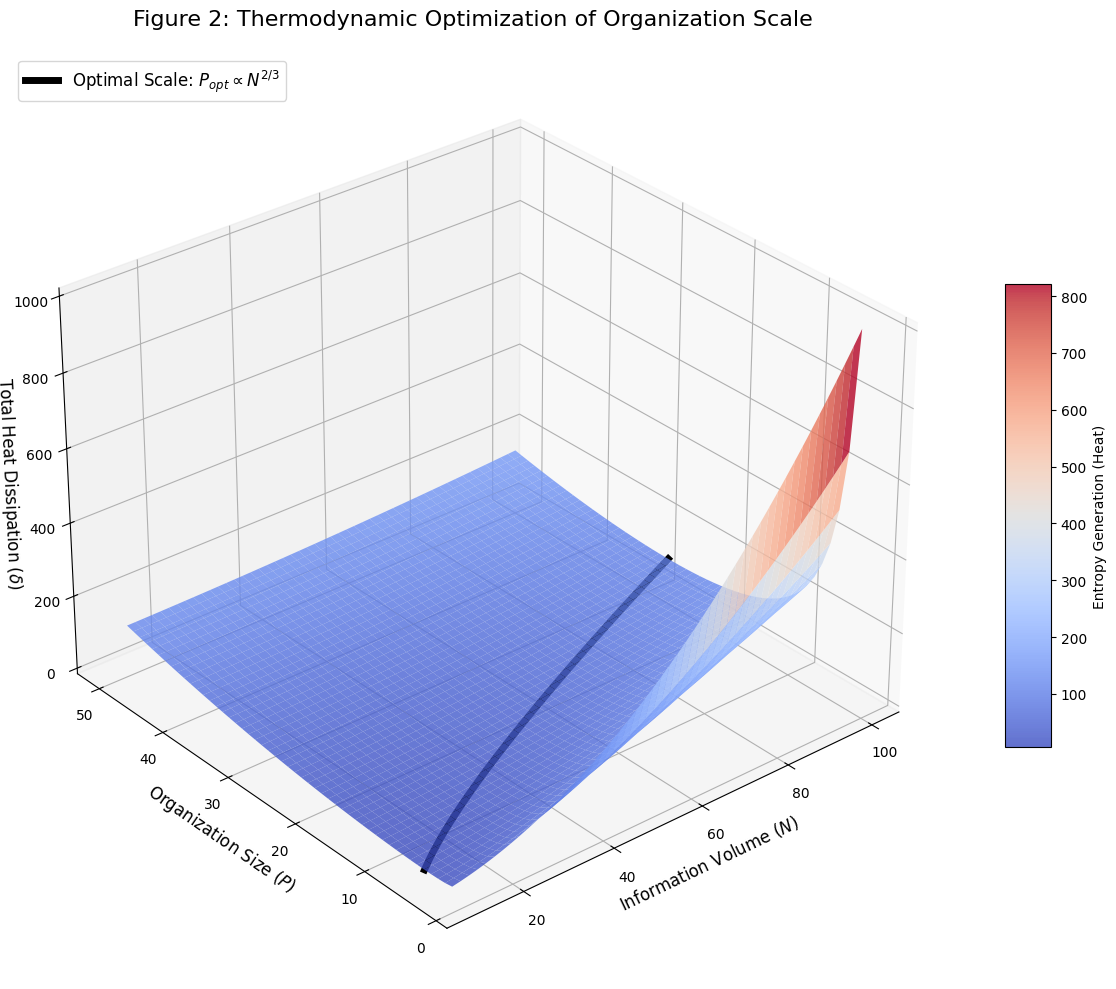

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
alpha = 0.2  # Coefficient for internal processing heat (Specialization gain)
gamma = 0.05 # Coefficient for coordination heat (Metcalfe's Law)

# Define ranges for N (Information Volume) and P (Organization Size)
n_range = np.linspace(10, 100, 50)
p_range = np.linspace(2, 50, 50)
N, P = np.meshgrid(n_range, p_range)

# Calculate Total Heat Dissipation: delta(P, N) = alpha * (N^2 / P) + gamma * P^2
Z = alpha * (N**2 / P) + gamma * (P**2)

# Calculate the Optimal Path: P_opt = (alpha / (2 * gamma))^(1/3) * N^(2/3)
N_line = np.linspace(10, 100, 100)
P_opt = (alpha / (2 * gamma))**(1/3) * (N_line**(2/3))
Z_opt = alpha * (N_line**2 / P_opt) + gamma * (P_opt**2)

# Visualization
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(N, P, Z, cmap='coolwarm', alpha=0.8, edgecolor='none')

# Plot the "Optimal Valley" line
ax.plot(N_line, P_opt, Z_opt, color='black', lw=5, label='Optimal Scale: $P_{opt} \propto N^{2/3}$')

# Labels and Titles (English for the paper)
ax.set_title('Figure 2: Thermodynamic Optimization of Organization Scale', fontsize=16, pad=20)
ax.set_xlabel('Information Volume ($N$)', fontsize=12)
ax.set_ylabel('Organization Size ($P$)', fontsize=12)
ax.set_zlabel('Total Heat Dissipation ($\delta$)', fontsize=12)

# Customizing the view for better understanding of the "valley"
ax.view_init(elev=30, azim=-130)

# Add colorbar
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10, label='Entropy Generation (Heat)')

plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()